In [27]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\hp\Desktop\e-commerce project\data
['analysis.ipynb', 'train.csv']


In [28]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Data Load
df = pd.read_csv('train.csv')
# Step 3: Basic Info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [29]:
# Data ka basic overview
print("=== DATASET INFO ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
df.describe()

=== DATASET INFO ===
Rows: 9800
Columns: 18

=== MISSING VALUES ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

=== DATA TYPES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

=== BASIC STATISTICS ===


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [30]:
# Postal Code ki missing values fix karo
df['Postal Code'] = df['Postal Code'].fillna(0)

# Order Date ko proper date format mein convert karo
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Confirm karo
print("Missing values after cleaning:")
print(df.isnull().sum().sum())
print("\nDate column type:", df['Order Date'].dtype)

Missing values after cleaning:
0

Date column type: datetime64[ns]


In [31]:
# Naye helpful columns banao
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

# Yearly Sales
print("=== YEARLY SALES ===")
print(df.groupby('Year')['Sales'].sum().round(2))

=== YEARLY SALES ===
Year
2015    479856.21
2016    459436.01
2017    600192.55
2018    722052.02
Name: Sales, dtype: float64


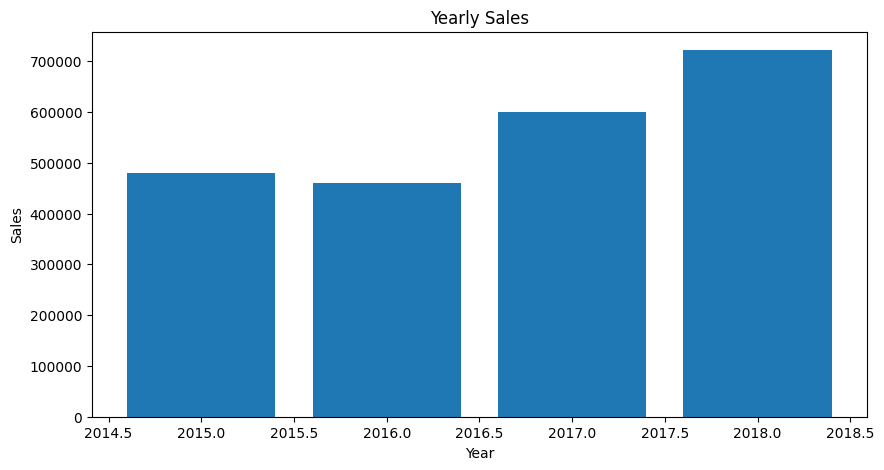

In [32]:
# Yearly Sales Bar Chart - Simple Version
yearly_sales = df.groupby('Year')['Sales'].sum().round(2)

plt.figure(figsize=(10, 5))
plt.bar(yearly_sales.index, yearly_sales.values)
plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

In [33]:
# Region wise Sales
region_sales = df.groupby('Region')['Sales'].sum().round(2)

print("=== REGION WISE SALES ===")
print(region_sales)

=== REGION WISE SALES ===
Region
Central    492646.91
East       669518.73
South      389151.46
West       710219.68
Name: Sales, dtype: float64


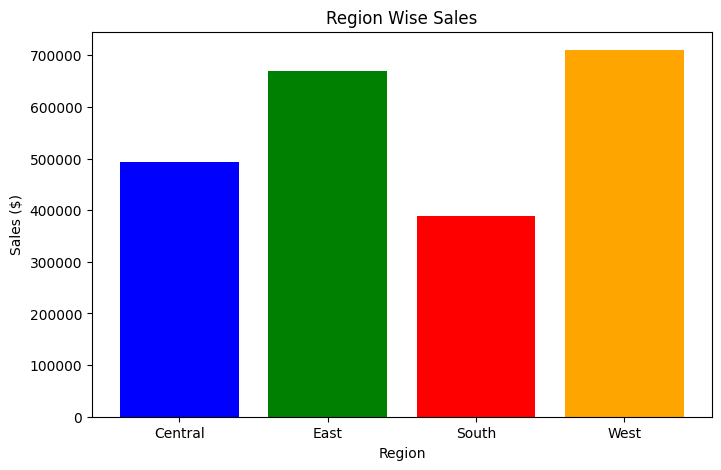

In [34]:
# Region Sales Chart
region_sales = df.groupby('Region')['Sales'].sum().round(2)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values, 
        color=['blue', 'green', 'red', 'orange'])
plt.title('Region Wise Sales')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.show()

=== CATEGORY WISE SALES ===
Category
Furniture          728658.58
Office Supplies    705422.33
Technology         827455.87
Name: Sales, dtype: float64


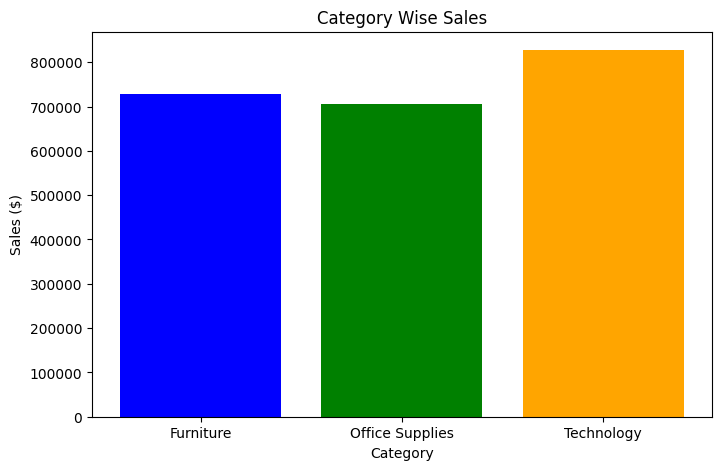

In [35]:
# Category wise Sales
category_sales = df.groupby('Category')['Sales'].sum().round(2)

print("=== CATEGORY WISE SALES ===")
print(category_sales)

# Chart
plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values,
        color=['blue', 'green', 'orange'])
plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.show()

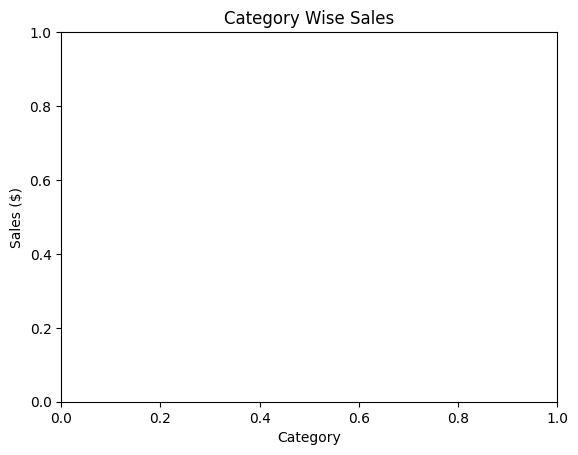

In [36]:
plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.show()

In [38]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name']


=== TOP SUB-CATEGORIES ===
Sub-Category
Phones         327782.45
Chairs         322822.73
Storage        219343.39
Tables         202810.63
Binders        200028.78
Machines       189238.63
Accessories    164186.70
Copiers        146248.09
Bookcases      113813.20
Appliances     104618.40
Furnishings     89212.02
Paper           76828.30
Supplies        46420.31
Art             26705.41
Envelopes       16128.05
Labels          12347.73
Fasteners        3001.96
Name: Sales, dtype: float64


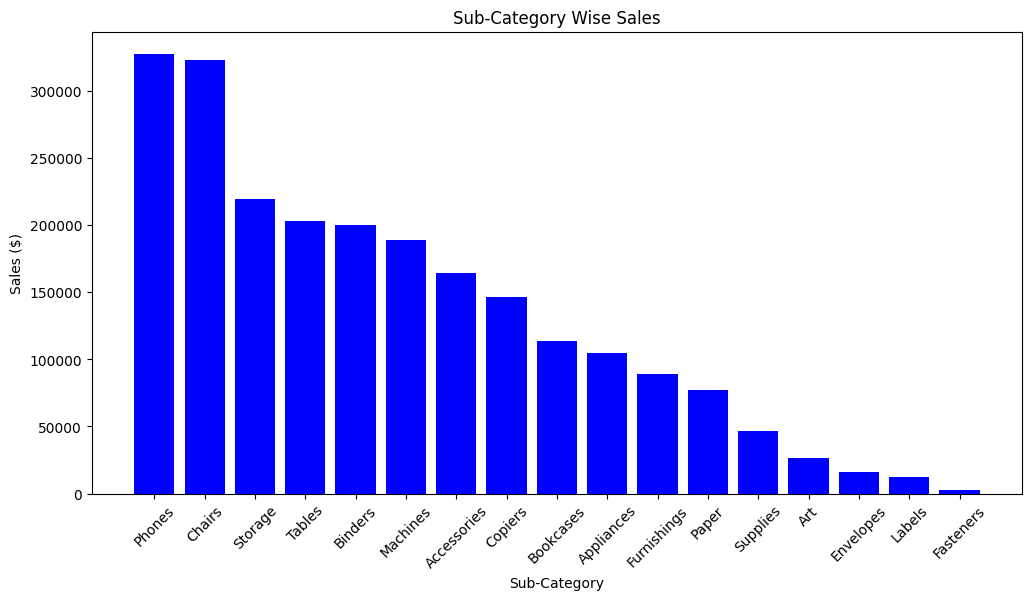

In [39]:
# Sub-Category wise Sales
sub_sales = df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False)

print("=== TOP SUB-CATEGORIES ===")
print(sub_sales)

# Chart
plt.figure(figsize=(12, 6))
plt.bar(sub_sales.index, sub_sales.values, color='blue')
plt.title('Sub-Category Wise Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()

=== TOP 10 CUSTOMERS ===
Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Name: Sales, dtype: float64


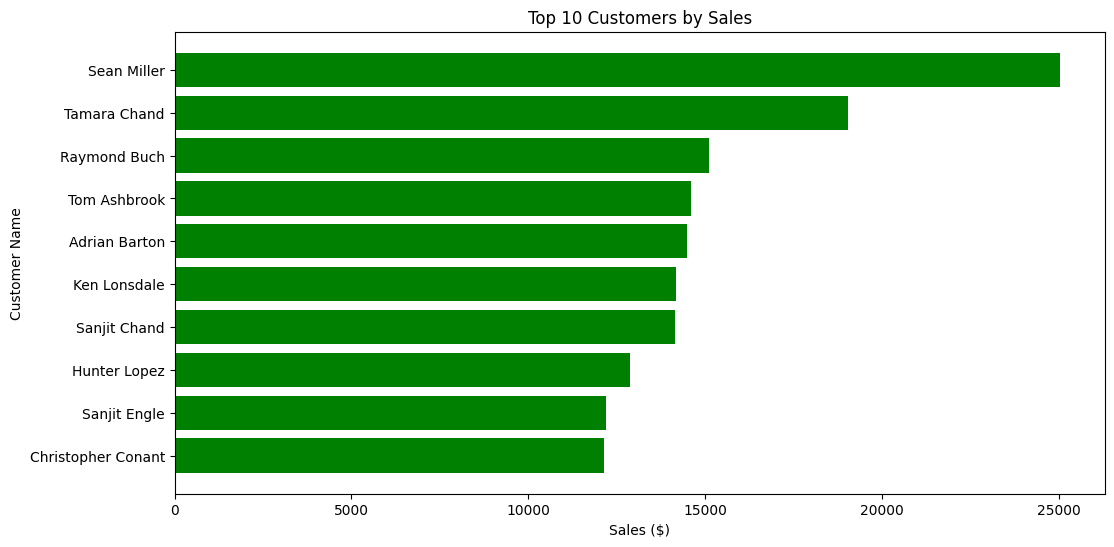

In [ ]:
# Top 10 Customers by Sales
top_customers = df.groupby('Customer Name')['Sales'].sum().round(2).sort_values(ascending=False).head(10)

print("=== TOP 10 CUSTOMERS ===")
print(top_customers)

# Chart
plt.figure(figsize=(12, 6))
plt.barh(top_customers.index, top_customers.values, color='green')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()
plt.show()


=== MONTHLY SALES ===
Month
1      94291.63
2      59371.12
3     197573.59
4     136283.00
5     154086.72
6     145837.52
7     145535.69
8     157315.93
9     300103.41
10    199496.29
11    350161.71
12    321480.17
Name: Sales, dtype: float64


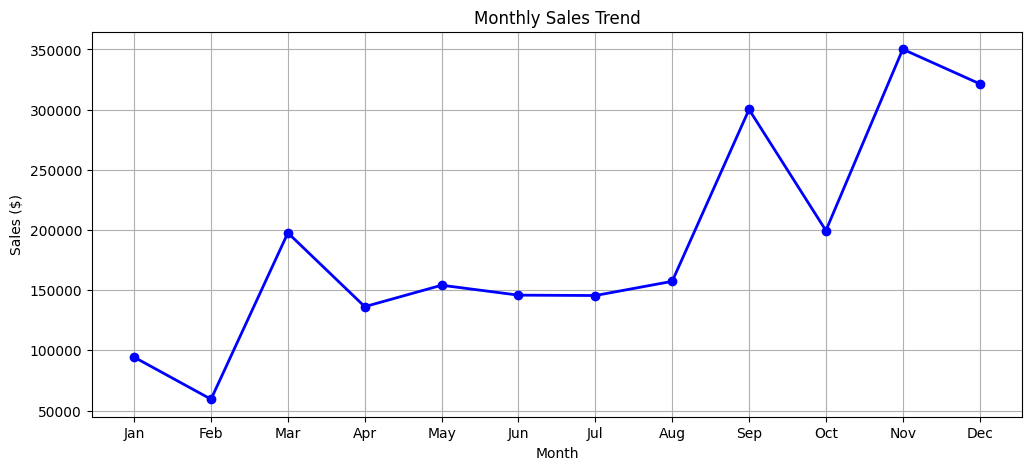

In [41]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Sales'].sum().round(2)

print("=== MONTHLY SALES ===")
print(monthly_sales)

# Line Chart - trend ke liye bar nahi line use karte!
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, 
         color='blue', marker='o', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.show()

In [42]:
# Clean data CSV mein save karo Power BI ke liye
df.to_csv('clean_data.csv', index=False)
print("✅ Data saved successfully!")
print(f"Total rows saved: {len(df)}")

✅ Data saved successfully!
Total rows saved: 9800


In [43]:
import os
print(os.listdir())

['analysis.ipynb', 'clean_data.csv', 'train.csv']
